## Bregman Divergence Example

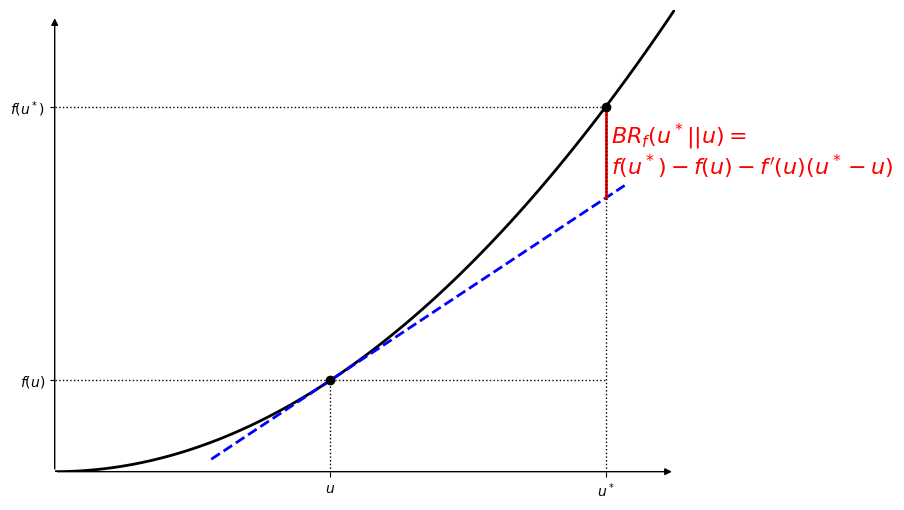

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x**2

def f_prime(x):
    return 2*x

x = np.linspace(0, 2.25, 100)
u1 = 1
u2 = 2

f_values = f(x)
tangent_line = f(u1) + f_prime(u1) * (x - u1)

plt.figure(figsize=(8, 6))
plt.plot(x, f_values, label=r"$f(x) = x^2$", linewidth=2, color='black')
plt.plot(x[25:92], tangent_line[25:92], '--', label=f"Tangent line at $u={u1}$", linewidth=2, color='blue')
plt.scatter(u1, f(u1), color='black', label=f"$u = {u1}$", zorder=5)
plt.scatter(u2, f(u2), color='black', label=f"$u^* = {u2}$", zorder=5)

x_fill = np.linspace(u1, u2, 100)

plt.plot([u2, u2], [f(u2) , f(u1) + f_prime(u1) * (u2 - u1)], '-', color='red', linewidth=2, label="Bregman Divergence Distance")
plt.text(u2 + 0.02, f(u2) - 0.4, f"$BR_f(u^* || u) = $", fontsize=16, color="red")
plt.text(u2 + 0.02, f(u2) - 0.75, f"$f(u^*) - f(u) - f'(u)(u^* - u)$", fontsize=16, color="red")

plt.plot([u1, u1], [0, f(u1)], color='black', linewidth=1, linestyle=':')
plt.plot([u2, u2], [0, f(u2)], color='black', linewidth=1, linestyle=':')
plt.plot([0, 2], [f(u1), f(u1)], color='black', linewidth=1, linestyle=':')
plt.plot([0, 2], [f(u2), f(u2)], color='black', linewidth=1, linestyle=':')

plt.xticks([u1, u2, ], [r"$u$", r"$u^*$",])
plt.yticks([f(u1), f(u2)], [f"$f(u)$", f"$f(u^*)$"])
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().margins(x=0,  y=0)
plt.annotate('', xy=(2.25, 0), xytext=(0, 0),
             arrowprops=dict(facecolor='black', arrowstyle='-|>'))
plt.annotate('', xy=(0, 5), xytext=(0, 0),
             arrowprops=dict(facecolor='black', arrowstyle='-|>'))

plt.show()

## Positive Unlabeled Data Example

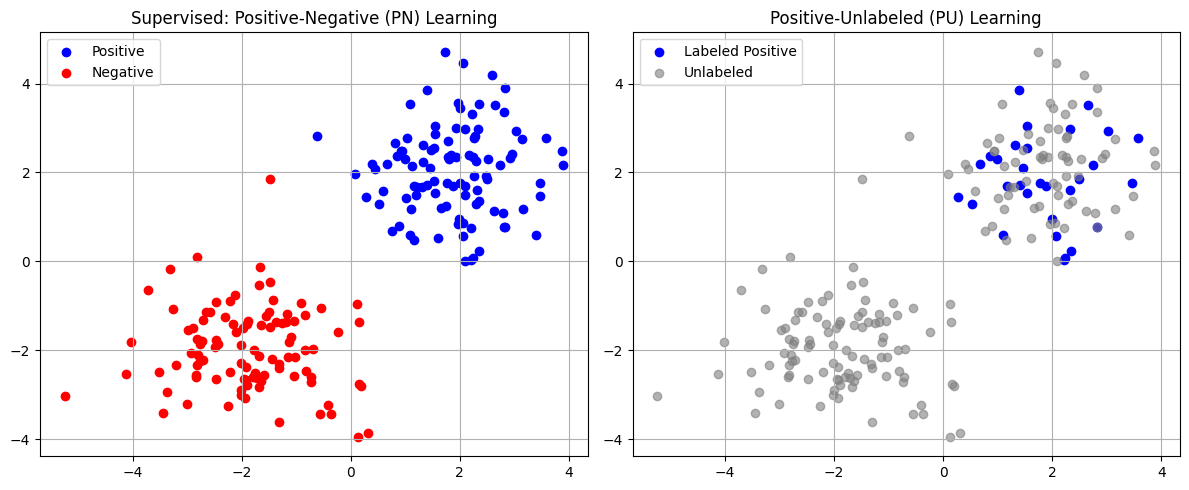

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)
n_pos = 100
n_neg = 100

X_pos = np.random.randn(n_pos, 2) + np.array([2, 2])
X_neg = np.random.randn(n_neg, 2) + np.array([-2, -2])

# PU setting
n_labeled_pos = 30
X_pos_labeled = X_pos[:n_labeled_pos]
X_unlabeled = np.vstack([X_pos[n_labeled_pos:], X_neg])

# Plot
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# PN
axs[0].scatter(X_pos[:, 0], X_pos[:, 1], color='blue', label='Positive')
axs[0].scatter(X_neg[:, 0], X_neg[:, 1], color='red', label='Negative')
axs[0].set_title('Supervised: Positive-Negative (PN) Learning')
axs[0].legend()
axs[0].grid(True)

# PU
axs[1].scatter(X_pos_labeled[:, 0], X_pos_labeled[:, 1], color='blue', label='Labeled Positive')
axs[1].scatter(X_unlabeled[:, 0], X_unlabeled[:, 1], color='gray', alpha=0.6, label='Unlabeled')
axs[1].set_title('Positive-Unlabeled (PU) Learning')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

## Label Shift Example

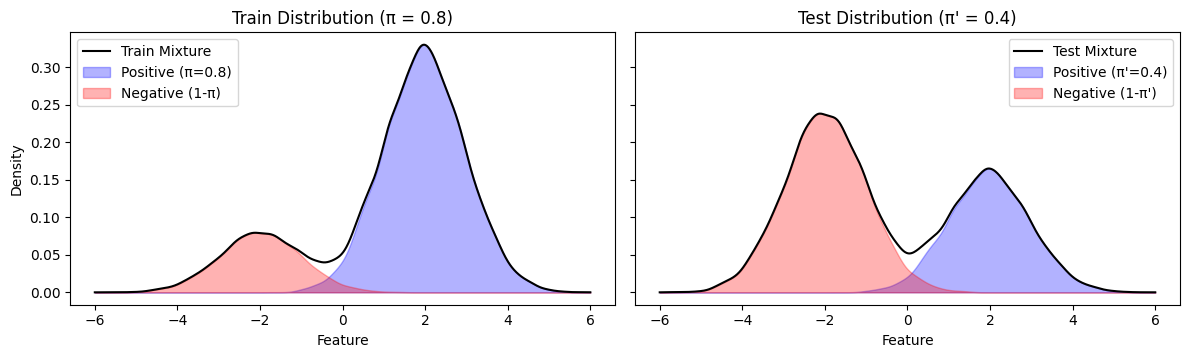

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Generate synthetic data
np.random.seed(0)
n = 10000
x_pos = np.random.normal(loc=2, scale=1, size=n)
x_neg = np.random.normal(loc=-2, scale=1, size=n)
x_grid = np.linspace(-6, 6, 1000)

# KDE estimates
kde_pos = gaussian_kde(x_pos)
kde_neg = gaussian_kde(x_neg)

p_pos = kde_pos(x_grid)
p_neg = kde_neg(x_grid)

pi_train = 0.8
p_train = pi_train * p_pos + (1 - pi_train) * p_neg

pi_test = 0.4
p_test = pi_test * p_pos + (1 - pi_test) * p_neg

# Plot
fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axs[0].plot(x_grid, p_train, label='Train Mixture', color='black')
axs[0].fill_between(x_grid, pi_train * p_pos, alpha=0.3, label='Positive (π=0.8)', color='blue')
axs[0].fill_between(x_grid, (1 - pi_train) * p_neg, alpha=0.3, label='Negative (1-π)', color='red')
axs[0].set_title("Train Distribution (π = 0.8)")
axs[0].set_xlabel("Feature")
axs[0].set_ylabel("Density")
axs[0].legend()

axs[1].plot(x_grid, p_test, label='Test Mixture', color='black')
axs[1].fill_between(x_grid, pi_test * p_pos, alpha=0.3, label="Positive (π'=0.4)", color='blue')
axs[1].fill_between(x_grid, (1 - pi_test) * p_neg, alpha=0.3, label="Negative (1-π')", color='red')
axs[1].set_title("Test Distribution (π' = 0.4)")
axs[1].set_xlabel("Feature")
axs[1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Sample Thresholds

In [7]:
import pandas as pd

pi_grid = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
thresholds_df = pd.DataFrame(columns=['pi', 'new_pi', 'threshold'])

for pi in pi_grid:
    for new_pi in pi_grid:
        threshold = (pi * (1 - new_pi)) / (pi + new_pi - 2 * pi * new_pi)
        thresholds_df = pd.concat([thresholds_df, pd.DataFrame({'pi': [pi], 'new_pi': [new_pi], 'threshold': [threshold]})], ignore_index=True)

thresholds_df_pivot = thresholds_df.pivot(index='pi', columns='new_pi', values='threshold')
thresholds_df_pivot.round(2)

new_pi,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
pi,,,,,,,,,
0.1,0.50,0.31,0.21,0.14,0.1,0.07,0.05,0.03,0.01
0.2,0.69,0.50,0.37,0.27,0.2,0.14,0.10,0.06,0.03
0.3,0.79,0.63,0.50,0.39,0.3,0.22,0.16,0.10,0.05
0.4,0.86,0.73,0.61,0.50,0.4,0.31,0.22,0.14,0.07
0.5,0.90,0.80,0.70,0.60,0.5,0.40,0.30,0.20,0.10
0.6,0.93,0.86,0.78,0.69,0.6,0.50,0.39,0.27,0.14
0.7,0.95,0.90,0.84,0.78,0.7,0.61,0.50,0.37,0.21
0.8,0.97,0.94,0.90,0.86,0.8,0.73,0.63,0.50,0.31
0.9,0.99,0.97,0.95,0.93,0.9,0.86,0.79,0.69,0.50


## Number of positive/unlabeled samples

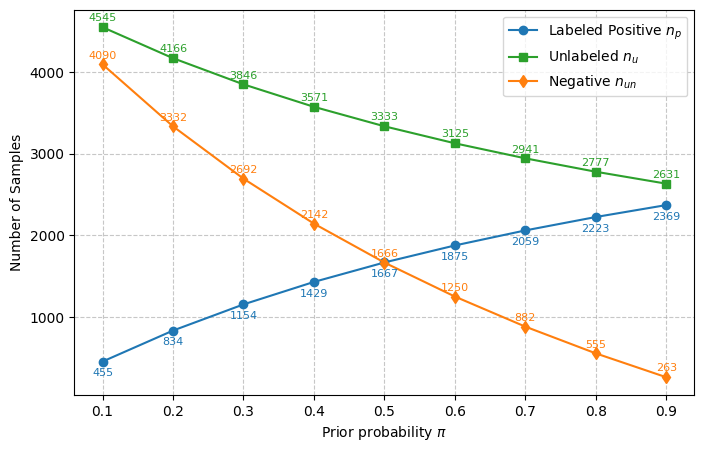

In [58]:
import numpy as np
import matplotlib.pyplot as plt

n_p_list = []
n_u_list = []
n_u_neg_list = []
c = 0.5
n_samples = 5000

for shifted_prior in np.linspace(0.1, 0.9, 9):
    A = 1 / (1 - c + c * shifted_prior)

    P_samples = int(np.ceil(A * c * (shifted_prior * n_samples)))
    U_samples = n_samples - P_samples
    n_u_pos = int(np.ceil(shifted_prior * U_samples))
    n_u_neg = U_samples - n_u_pos

    n_p_list.append(P_samples)
    n_u_list.append(U_samples)
    n_u_neg_list.append(n_u_neg)

plt.figure(figsize=(8, 5))
plt.plot(np.linspace(0.1, 0.9, 9), n_p_list, 'o-', label='Labeled Positive $n_p$', color='tab:blue')
plt.plot(np.linspace(0.1, 0.9, 9), n_u_list, 's-', label='Unlabeled $n_u$', color='tab:green')
plt.plot(np.linspace(0.1, 0.9, 9), n_u_neg_list, 'd-', label='Negative $n_{un}$', color='tab:orange')
# annotate numbers
for threshold, n_p, n_u, n_u_neg in zip(np.linspace(0.1, 0.9, 9), n_p_list, n_u_list, n_u_neg_list):
    plt.text(threshold, n_p - 200, f"{n_p}", ha='center', va='bottom', fontsize=8, color='tab:blue')
    plt.text(threshold, n_u + 50, f"{n_u}", ha='center', va='bottom', fontsize=8, color='tab:green')
    plt.text(threshold, n_u_neg + 50, f"{n_u_neg}", ha='center', va='bottom', fontsize=8, color='tab:orange')
plt.xlabel('Prior probability $\\pi$')
plt.ylabel('Number of Samples')
plt.legend()
ax = plt.gca()
ax.yaxis.grid(True, linestyle="--", alpha=0.7)
ax.xaxis.grid(True, linestyle="--", alpha=0.7)
plt.show()


## Accuracy as function of threshold for Positive/Negative Data under Label Shift Example

In [38]:
# Simulation of accuracy as function of threshold
# Gaussian distribution mean=0.5, n=5000

from nnPU.src.nnPUss.model import PUModel

from sklearn import metrics
import torch 

K = 10
n = 5000
mean = 0.5
n_epochs = 25

results = {}
for (train_pi, test_pi) in [(0.25, 0.5), (0.5, 0.25), (0.5, 0.75), (0.75, 0.5)]:
    results[(train_pi, test_pi)] = []

    for exp_number in range(K):

        torch.manual_seed(42 + exp_number)
        np.random.seed(42 + exp_number)

        train_data = torch.cat(
            [
                torch.normal(0, 1, (int(n * train_pi), 10)),
                torch.normal(mean, 1, (int(n * (1 - train_pi)), 10)),
            ]
        )
        train_labels = torch.cat(
            [
                torch.ones(int(n * train_pi)),
                torch.zeros(int(n * (1 - train_pi))),
            ]
        )
        test_data = torch.cat(
            [
                torch.normal(0, 1, (int(n * test_pi), 10)),
                torch.normal(mean, 1, (int(n * (1 - test_pi)), 10)),
            ]
        )   
        test_labels = torch.cat(
            [
                torch.ones(int(n * test_pi)),
                torch.zeros(int(n * (1 - test_pi))),
            ]
        )

        train_loader = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(train_data, train_labels), batch_size=64, shuffle=True
        )
        test_loader = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(test_data, test_labels), batch_size=64, shuffle=True
        )

        model = PUModel(n_inputs=10)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.005, betas=(0.9, 0.999))
        loss_fn = torch.nn.BCEWithLogitsLoss()

        # train loop
        model.train()
        for epoch in range(n_epochs):
            tr_loss = 0
            outputs = []
            labels = []
            for batch_data, batch_labels in train_loader:
                optimizer.zero_grad()
                batch_outputs = model(batch_data)
                outputs.append(batch_outputs.detach())
                labels.append(batch_labels)
                loss = loss_fn(batch_outputs.squeeze(), batch_labels)
                tr_loss += loss.item()
                loss.backward()
                optimizer.step()
            # posterior 
            preds = torch.sigmoid(torch.cat(outputs)).numpy()
            acc = metrics.accuracy_score(torch.cat(labels).numpy(), (preds > 0.5).astype(int))
            print(f"Epoch {epoch+1}/{n_epochs}, Loss: {tr_loss:.4f}, Accuracy: {acc:.4f}")
                
        # test loop
        model.eval()
        outputs = []
        labels = []
        with torch.no_grad():
            for batch_data, batch_labels in test_loader:
                batch_outputs = model(batch_data)
                outputs.append(batch_outputs.detach())
                labels.append(batch_labels)


        preds = torch.sigmoid(torch.cat(outputs)).numpy()
        acc = metrics.accuracy_score(torch.cat(labels).squeeze().detach().numpy(), (preds > 0.5).astype(int))
        print(f"Test Accuracy: {acc:.4f}")

        # Accuracy as function of threshold
        thresholds = np.linspace(0, 1, 100)
        accuracies = []
        for threshold in thresholds:
            acc = metrics.accuracy_score(torch.cat(labels).squeeze().detach().numpy(), (preds > threshold).astype(int))
            accuracies.append(acc) 
        
        results[(train_pi, test_pi)].append((accuracies))

Epoch 1/25, Loss: 34.5882, Accuracy: 0.7936
Epoch 2/25, Loss: 30.9464, Accuracy: 0.8228
Epoch 3/25, Loss: 30.9399, Accuracy: 0.8202
Epoch 4/25, Loss: 30.9744, Accuracy: 0.8208
Epoch 5/25, Loss: 31.6873, Accuracy: 0.8170
Epoch 6/25, Loss: 31.5473, Accuracy: 0.8236
Epoch 7/25, Loss: 31.3802, Accuracy: 0.8216
Epoch 8/25, Loss: 30.9864, Accuracy: 0.8228
Epoch 9/25, Loss: 30.6849, Accuracy: 0.8208
Epoch 10/25, Loss: 30.8903, Accuracy: 0.8240
Epoch 11/25, Loss: 30.5182, Accuracy: 0.8216
Epoch 12/25, Loss: 30.5598, Accuracy: 0.8272
Epoch 13/25, Loss: 30.8065, Accuracy: 0.8238
Epoch 14/25, Loss: 31.0392, Accuracy: 0.8200
Epoch 15/25, Loss: 31.0551, Accuracy: 0.8234
Epoch 16/25, Loss: 30.8777, Accuracy: 0.8236
Epoch 17/25, Loss: 31.3341, Accuracy: 0.8254
Epoch 18/25, Loss: 30.8892, Accuracy: 0.8212
Epoch 19/25, Loss: 31.1972, Accuracy: 0.8240
Epoch 20/25, Loss: 30.8526, Accuracy: 0.8272
Epoch 21/25, Loss: 31.8744, Accuracy: 0.8228
Epoch 22/25, Loss: 30.6607, Accuracy: 0.8248
Epoch 23/25, Loss: 

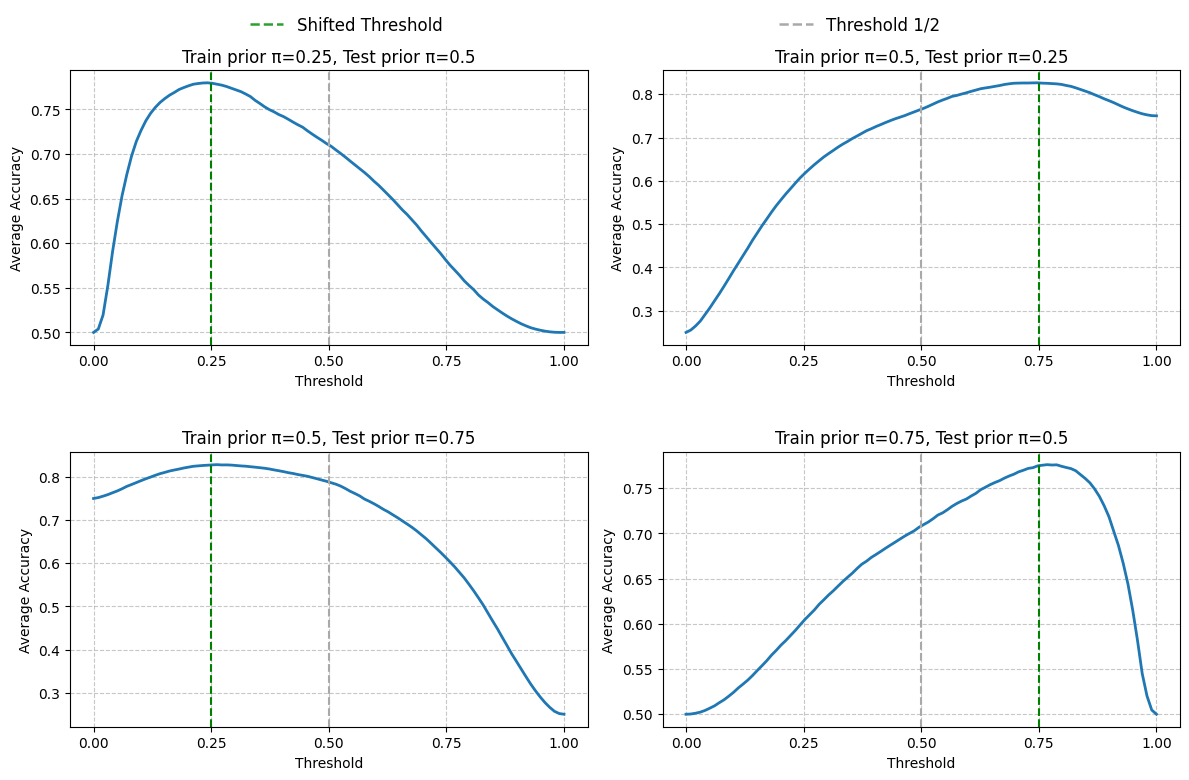

In [47]:
# 4 plots for each (train_pi, test_pi) pair

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

thresholds = np.linspace(0, 1, 100)
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
for (train_pi, test_pi) in [(0.25, 0.5), (0.5, 0.25), (0.5, 0.75), (0.75, 0.5)]:
    avg_accuracies = np.mean([res for res in results[(train_pi, test_pi)]], axis=0)
    shifted_threshold = (train_pi * (1 - test_pi)) / (train_pi + test_pi - 2 * train_pi * test_pi)
    ax = axs[0, 0] if (train_pi, test_pi) == (0.25, 0.5) else axs[0, 1] if (train_pi, test_pi) == (0.5, 0.25) else axs[1, 0] if (train_pi, test_pi) == (0.5, 0.75) else axs[1, 1]
    ax.plot(thresholds, avg_accuracies, linewidth=2)
    ax.axvline(x=shifted_threshold, color='green', linestyle='--', label=f'Shifted Threshold={shifted_threshold:.2f}')
    ax.axvline(x=0.5, color='darkgrey', linestyle='--', label='Standard Threshold=0.5')
    ax.set_title(f"Train prior π={train_pi}, Test prior π={test_pi}")
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Average Accuracy')
    ax.grid(True, linestyle="--", alpha=0.7)
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1])

legend_handles = [
        Line2D([0], [0], color="tab:green", linestyle="--", linewidth=1.8, label="Shifted Threshold"),
        Line2D([0], [0], color="darkgrey", linestyle="--", linewidth=1.8, label="Threshold 1/2"),
    ]
fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.2, 0.93, 0.6, 0.05),
    mode="expand",
    fontsize=12,
)
plt.tight_layout(h_pad=3.0, rect=[0, 0, 1, 0.94])
plt.show()